# 07. Policy results

This notebook summarizes the model-implied three-policy comparison. It reports terminal correction, the value components across reimbursement share and weekly capacity, and the product and week contributions to selected policy differences.

The primary outcome is the value of dynamic optimization,
\[
\mathrm{VDO}=V(\pi^D)-V(\pi^M).
\]
Because dynamic optimization can select the myopic calendar, positive VDO is an implementation requirement rather than the main substantive finding. The empirical analysis therefore focuses on the magnitude, localization, and composition of the gain.

All reported values are conditional on the calibrated demand-displacement model, the supported action sets, and the assumed funding environment. They should not be interpreted as causal estimates of the profit effect of implementing the recommended calendars.

## 1. Load the selected policy artifact

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Suppress pandas transition warnings so the notebook output remains focused on
# substantive diagnostics.
warnings.filterwarnings("ignore", category=FutureWarning)

# Locate the repository root from either the project root or notebooks folder.
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    (
        root
        for root in [CURRENT_DIR, *CURRENT_DIR.parents]
        if (root / "pyproject.toml").is_file()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the project root. "
        "Run the notebook from the repository or notebooks directory."
    )

# Make the local package importable without requiring an editable installation.
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from dynamic_promotion_planning.policy import (
    load_pickle,
    save_pickle,
)
from dynamic_promotion_planning.boundaries import (
    build_policy_switch_table,
)

# Canonical artifact and reporting directories.
POLICY_ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "policy"
TABLE_DIR = PROJECT_ROOT / "results" / "final" / "tables"
FIGURE_DIR = PROJECT_ROOT / "results" / "final" / "figures"

for directory in [
    POLICY_ARTIFACT_DIR,
    TABLE_DIR,
    FIGURE_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

In [2]:
# Load the complete policy-optimization artifact created by Notebook 06.
POLICY_ARTIFACT_PATH = POLICY_ARTIFACT_DIR / "policy_optimization.pkl"

if not POLICY_ARTIFACT_PATH.is_file():
    raise FileNotFoundError(
        f"Missing {POLICY_ARTIFACT_PATH}. Run Notebook 06 first."
    )

artifact = load_pickle(POLICY_ARTIFACT_PATH)

# Recover the policy grid, washout diagnostics, and additive decompositions.
policy_results = (
    artifact["policy_results"]
    .copy()
    .sort_values(["capacity", "alpha"])
    .reset_index(drop=True)
)
washout_results = artifact["washout_results"].copy()
washout_stability = artifact["washout_stability"].copy()
product_decomposition = artifact["product_decomposition"].copy()
weekly_decomposition = artifact["weekly_decomposition"].copy()

if policy_results.empty:
    raise RuntimeError("The policy-results artifact contains no grid rows.")

if washout_results.empty or washout_stability.empty:
    raise RuntimeError("The terminal-washout diagnostics are empty.")

if product_decomposition.empty or weekly_decomposition.empty:
    raise RuntimeError("At least one policy decomposition is empty.")

# Recover schedules and calibrated inputs needed for boundary analysis.
schedules = artifact["schedules"]
draws_by_product = artifact["draws_by_product"]
weekly_profiles = artifact["weekly_profiles"]
action_sets = artifact["action_sets"]
support_table = artifact["support_table"]
products = list(artifact["products"])
planning = artifact["schedule_system"]["planning"]

SELECTED_WASHOUT = int(artifact["selected_washout"])
CAPACITIES = list(artifact["capacities"])
ECONOMIC_PROFILE_MODE = str(artifact["economic_profile_mode"])

# Confirm that the demand-only economic specification was preserved.
if not all(
    np.allclose(np.asarray(values["price_factor"], dtype=float), 1.0)
    for values in weekly_profiles.values()
):
    raise AssertionError(
        "Price factors are not fixed to one in the final artifact."
    )

if not all(
    np.allclose(np.asarray(values["cost_factor"], dtype=float), 1.0)
    for values in weekly_profiles.values()
):
    raise AssertionError(
        "Cost factors are not fixed to one in the final artifact."
    )

print("Selected washout:", SELECTED_WASHOUT)
print("Policy rows:", len(policy_results))

Selected washout: 36
Policy rows: 404


## 2. Terminal-washout sensitivity

The selected washout is the shortest evaluated horizon satisfying the pre-specified VDO-stability and terminal-state criteria.

In [3]:
# Display the washout-selection diagnostics and mark the selected horizon.
washout_stability_display = washout_stability.copy()
washout_stability_display["selected"] = (
    washout_stability_display["washout_horizon"].eq(SELECTED_WASHOUT)
)

display(washout_stability_display)

,washout_horizon,maximum_absolute_vdo_change,maximum_terminal_state,vdo_stable,terminal_state_small,selected
0,36,NaN,0.008271,False,True,True


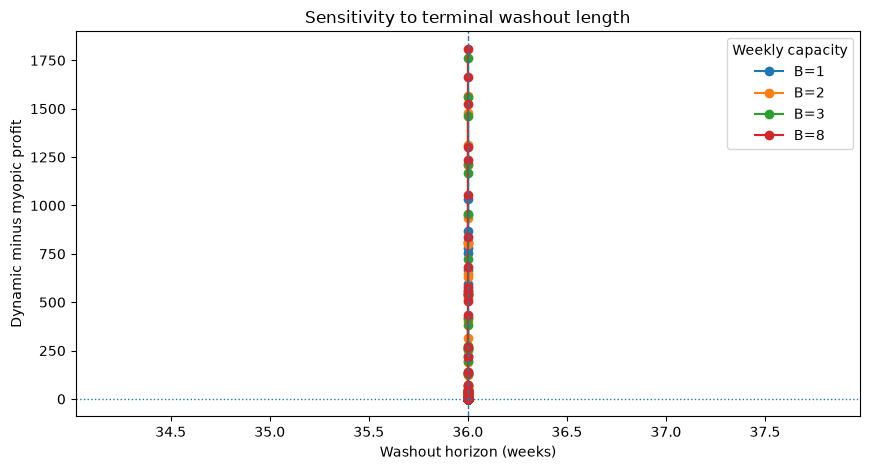

In [4]:
# Plot how VDO changes as delayed post-promotion effects are brought inside
# the evaluation window.
fig, ax = plt.subplots(figsize=(8.8, 4.8))

for capacity, group in washout_results.groupby(
    "capacity",
    observed=True,
):
    group = group.sort_values("washout_horizon")
    ax.plot(
        group["washout_horizon"],
        group["vdo"],
        marker="o",
        label=f"B={capacity}",
    )

ax.axhline(0.0, linestyle=":", linewidth=1.0)
ax.axvline(SELECTED_WASHOUT, linestyle="--", linewidth=1.0)
ax.set_xlabel("Washout horizon (weeks)")
ax.set_ylabel("Dynamic minus myopic profit")
ax.set_title("Sensitivity to terminal washout length")
ax.legend(title="Weekly capacity")
fig.tight_layout()

for suffix in ["png", "pdf"]:
    figure_path = FIGURE_DIR / f"vdo_washout_stability.{suffix}"
    fig.savefig(
        figure_path,
        dpi=300 if suffix == "png" else None,
        bbox_inches="tight",
    )

plt.show()

## 3. Identify discrete policy transitions

In [5]:
# Compare each policy signature with the preceding funding value within the same
# capacity. A change indicates a discrete boundary in the selected calendar or
# set of promoted product-week actions.
policy_regimes = policy_results.copy()

for signature_column in [
    "dynamic_schedule_signature",
    "myopic_schedule_signature",
    "dynamic_active_set",
    "myopic_active_set",
]:
    policy_regimes[f"{signature_column}_previous"] = (
        policy_regimes.groupby(
            "capacity",
            observed=True,
        )[signature_column].shift()
    )

policy_regimes["dynamic_schedule_change"] = (
    policy_regimes["dynamic_schedule_signature"]
    != policy_regimes["dynamic_schedule_signature_previous"]
)

policy_regimes["myopic_schedule_change"] = (
    policy_regimes["myopic_schedule_signature"]
    != policy_regimes["myopic_schedule_signature_previous"]
)

policy_regimes["dynamic_active_set_change"] = (
    policy_regimes["dynamic_active_set"]
    != policy_regimes["dynamic_active_set_previous"]
)

In [6]:
# Complete the boundary flags for the myopic active set.
policy_regimes["myopic_active_set_change"] = (
    policy_regimes["myopic_active_set"]
    != policy_regimes["myopic_active_set_previous"]
)

# The first funding value within each capacity has no preceding grid point and
# therefore cannot be classified as a policy transition.
first_rows = (
    policy_regimes.groupby(
        "capacity",
        observed=True,
    ).cumcount().eq(0)
)

for column in [
    "dynamic_schedule_change",
    "myopic_schedule_change",
    "dynamic_active_set_change",
    "myopic_active_set_change",
]:
    policy_regimes.loc[first_rows, column] = False

# Mark a grid point whenever at least one dynamic or myopic policy object changes.
policy_regimes["any_policy_boundary"] = (
    policy_regimes[
        [
            "dynamic_schedule_change",
            "myopic_schedule_change",
            "dynamic_active_set_change",
            "myopic_active_set_change",
        ]
    ].any(axis=1)
)

# Scale the best-versus-second-best gap by absolute dynamic profit to make the
# local degree of schedule separation comparable across grid points.
policy_regimes["relative_best_second_gap"] = (
    policy_regimes["best_second_gap"]
    / policy_regimes["dynamic_profit"].abs()
)

In [7]:
# Inspect the first policy boundaries and their associated VDO values.
display(
    policy_regimes.loc[
        policy_regimes["any_policy_boundary"],
        [
            "alpha",
            "capacity",
            "vdo",
            "vdo_percent",
            "best_second_gap",
            "dynamic_schedule_change",
            "myopic_schedule_change",
            "dynamic_active_set_change",
            "myopic_active_set_change",
        ],
    ].head(40)
)

,alpha,capacity,vdo,vdo_percent,best_second_gap,dynamic_schedule_change,myopic_schedule_change,dynamic_active_set_change,myopic_active_set_change
75,0.75,1,40.920426,0.014045,9.098379,False,True,False,True
78,0.78,1,37.288236,0.012798,0.287785,False,True,False,True
79,0.79,1,43.570654,0.014954,0.012324,True,True,True,True
81,0.81,1,21.000507,0.007207,0.000283,True,True,True,False
82,0.82,1,16.619840,0.005703,8.076096,True,False,False,False
83,0.83,1,129.418518,0.044423,15.310691,False,True,False,False
84,0.84,1,64.965433,0.022293,0.122871,True,True,False,False
85,0.85,1,50.162373,0.017208,0.673397,True,False,True,False
86,0.86,1,39.594379,0.013579,0.197379,True,False,False,False
87,0.87,1,222.167617,0.076219,0.441961,False,True,False,False


In [8]:
# Identify the largest VDO point within each capacity. These rows summarize
# where the model assigns the greatest value to forward-looking planning.
top_vdo_by_capacity = (
    policy_regimes.loc[
        policy_regimes.groupby(
            "capacity",
            observed=True,
        )["vdo"].idxmax(),
        [
            "capacity",
            "alpha",
            "vdo",
            "vdo_percent",
            "best_second_gap",
            "action_disagreements",
            "status_disagreements",
            "depth_disagreements",
            "timing_shift_products",
        ],
    ]
    .sort_values("capacity")
    .reset_index(drop=True)
)

display(top_vdo_by_capacity)

,capacity,alpha,vdo,vdo_percent,best_second_gap,action_disagreements,status_disagreements,depth_disagreements,timing_shift_products
0,1,0.90,1035.638037,0.355421,0.640448,24,24,0,2
1,2,0.89,1567.357146,0.539369,18.835842,32,32,0,4
2,3,0.90,1764.336889,0.606858,0.081334,36,36,0,3
3,8,0.90,1809.281534,0.622407,0.019760,44,44,0,4


## 4. Reimbursement-share and capacity policy results

This section reports how VDO changes across the evaluated funding and capacity grid.

In [9]:
# Report the policy comparison at the pre-specified main funding value.
scenario_rows = policy_results.copy()

if scenario_rows.empty:
    available_alphas = np.sort(
        policy_results["alpha"].unique()
    )

    raise RuntimeError(
        f"No reimbursement scenarios were found. "
        f"Available values are: {available_alphas}."
    )

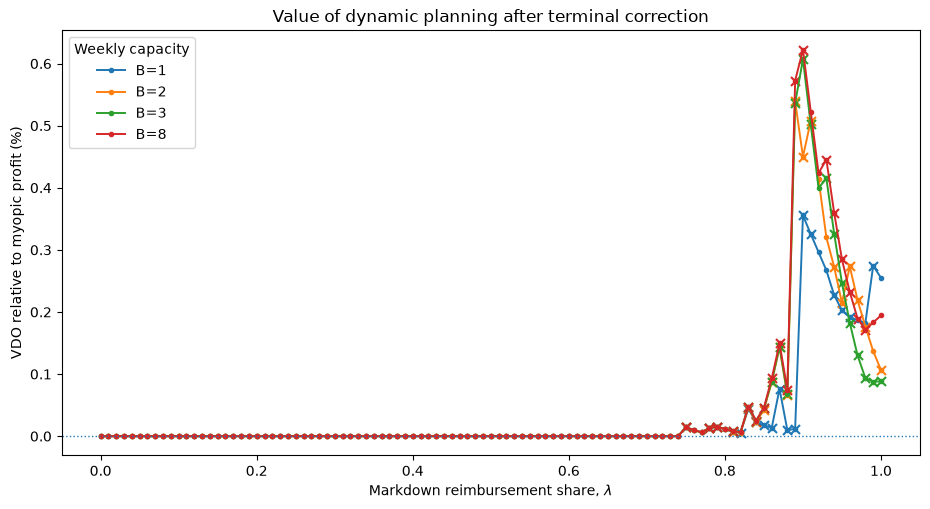

In [10]:
# Plot relative VDO across funding values and mark discrete policy boundaries.
fig, ax = plt.subplots(figsize=(9.4, 5.2))

for capacity, group in policy_regimes.groupby(
    "capacity",
    observed=True,
):
    group = group.sort_values("alpha")
    ax.plot(
        group["alpha"],
        group["vdo_percent"],
        marker="o",
        markersize=3,
        linewidth=1.4,
        label=f"B={capacity}",
    )

    boundary_group = group.loc[group["any_policy_boundary"]]
    ax.scatter(
        boundary_group["alpha"],
        boundary_group["vdo_percent"],
        marker="x",
        s=42,
    )

ax.axhline(0.0, linestyle=":", linewidth=1.0)
ax.set_xlabel(r"Markdown reimbursement share, $\lambda$")
ax.set_ylabel("VDO relative to myopic profit (%)")
ax.set_title("Value of dynamic planning after terminal correction")
ax.legend(title="Weekly capacity")
fig.tight_layout()

for suffix in ["png", "pdf"]:
    figure_path = FIGURE_DIR / f"vdo_percent_by_reimbursement_capacity.{suffix}"
    fig.savefig(
        figure_path,
        dpi=300 if suffix == "png" else None,
        bbox_inches="tight",
    )

plt.show()

Cross markers identify reimbursement-share values at which at least one calendar changes relative to the preceding grid point. They indicate discrete policy boundaries, not statistical significance.

## 5. Additive decomposition by product and week

In [11]:
# Use capacity two as the primary decomposition example.
MAIN_CAPACITY = 2

capacity_rows = policy_results.loc[
    policy_results["capacity"].eq(MAIN_CAPACITY)
].copy()

if capacity_rows.empty:
    raise RuntimeError(
        f"No policy results are available for capacity {MAIN_CAPACITY}."
    )

# Use the maximum-VDO scenario at this capacity for decomposition.
boundary_row = (
    capacity_rows.sort_values(
        "vdo",
        ascending=False,
    ).iloc[0]
)
BOUNDARY_ALPHA = float(boundary_row["alpha"])

DECOMPOSITION_ALPHAS = [round(BOUNDARY_ALPHA, 8)]

print("Decomposition alphas:", DECOMPOSITION_ALPHAS)

Decomposition alphas: [0.89]


In [12]:
# Restrict the stored product and week decompositions to the selected capacity
# and funding values.
selected_product_decomposition = product_decomposition.loc[
    product_decomposition["capacity"].eq(MAIN_CAPACITY)
    & product_decomposition["alpha"].round(8).isin(DECOMPOSITION_ALPHAS)
].copy()

selected_weekly_decomposition = weekly_decomposition.loc[
    weekly_decomposition["capacity"].eq(MAIN_CAPACITY)
    & weekly_decomposition["alpha"].round(8).isin(DECOMPOSITION_ALPHAS)
].copy()

if selected_product_decomposition.empty:
    raise RuntimeError(
        "No product decomposition rows match the selected capacity and alphas."
    )

if selected_weekly_decomposition.empty:
    raise RuntimeError(
        "No weekly decomposition rows match the selected capacity and alphas."
    )

# Sum contributions independently by product and week. Both should reproduce
# total VDO for each selected funding value.
product_accounting_check = (
    selected_product_decomposition.groupby(
        "alpha",
        observed=True,
    )["vdo_contribution"].sum()
)

weekly_accounting_check = (
    selected_weekly_decomposition.groupby(
        "alpha",
        observed=True,
    )["vdo_contribution"].sum()
)

In [13]:
# Display the two additive accounting identities side by side.
accounting_check = pd.concat(
    [
        product_accounting_check.rename("product_sum"),
        weekly_accounting_check.rename("weekly_sum"),
    ],
    axis=1,
)

if not np.allclose(
    accounting_check["product_sum"],
    accounting_check["weekly_sum"],
    atol=1e-6,
    rtol=1e-8,
):
    raise AssertionError(
        "Product and weekly VDO decompositions do not agree."
    )

display(accounting_check)

,product_sum,weekly_sum
alpha,,
0.89,1567.357146,1567.357146


In [14]:
# Rank products by their contribution to dynamic-minus-myopic profit.
product_rankings = selected_product_decomposition.sort_values(
    ["alpha", "vdo_contribution"],
    ascending=[True, False],
)

display(
    product_rankings[
        [
            "alpha",
            "upc",
            "dynamic_profit",
            "myopic_profit",
            "vdo_contribution",
        ]
    ]
)

# Aggregate weekly contributions by decision-week indicator to distinguish the
# planning horizon from the no-promotion washout period.
washout_attribution = (
    selected_weekly_decomposition.groupby(
        ["alpha", "decision_week"],
        observed=True,
    )["vdo_contribution"]
    .sum()
    .rename("vdo_contribution")
    .reset_index()
)

display(washout_attribution)

,alpha,upc,dynamic_profit,myopic_profit,vdo_contribution
1527,0.89,3800001611,34897.850431,33876.037103,1021.813328
1521,0.89,1600066590,49564.149503,49091.512253,472.637250
1526,0.89,3800001520,32297.016036,32251.950593,45.065443
1524,0.89,3800000120,24347.624238,24325.726317,21.897921
1523,0.89,3800000110,18340.620001,18331.951707,8.668295
1520,0.89,1600066510,46828.836047,46828.836047,0.000000
1522,0.89,1600066610,68442.577038,68442.577038,0.000000
1525,0.89,3800000127,17439.645023,17442.370114,-2.725091


,alpha,decision_week,vdo_contribution
0,0.89,False,188.453093
1,0.89,True,1378.904052


C:\Users\janza\AppData\Local\Temp\ipykernel_9844\2895646883.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


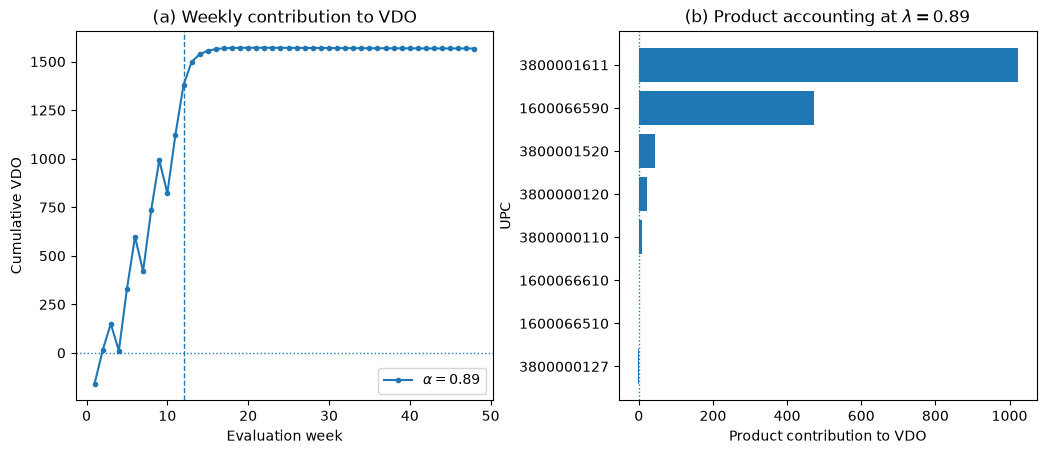

In [15]:
# Plot cumulative VDO over the evaluation horizon for the selected funding
# values. The vertical line marks the end of the decision horizon.
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.8),
                        gridspec_kw={"width_ratios": [1.0, 1.0], "wspace": 0.30})

for alpha, group in selected_weekly_decomposition.groupby(
    "alpha",
    observed=True,
):
    group = group.sort_values("week")
    axes[0].plot(
        group["week"],
        group["cumulative_vdo"],
        marker="o",
        markersize=3,
        label=rf"$\alpha={alpha:.2f}$",
    )

axes[0].axvline(
    planning.decision_horizon,
    linestyle="--",
    linewidth=1.0,
)
axes[0].axhline(0.0, linestyle=":", linewidth=1.0)

axes[0].set_xlabel("Evaluation week")
axes[0].set_ylabel("Cumulative VDO")
axes[0].set_title("(a) Weekly contribution to VDO")
axes[0].legend()

# Plot the product-level accounting at the maximum-VDO scenario.
main_product = (
    selected_product_decomposition.loc[
        np.isclose(
            selected_product_decomposition["alpha"],
            BOUNDARY_ALPHA,
        )
    ]
    .sort_values("vdo_contribution")
)

if main_product.empty:
    raise RuntimeError(
        "No product decomposition is available at the maximum-VDO scenario."
    )

axes[1].barh(
    main_product["upc"].astype(str),
    main_product["vdo_contribution"],
)
axes[1].axvline(0.0, linestyle=":", linewidth=1.0)

axes[1].set_xlabel("Product contribution to VDO")
axes[1].set_ylabel("UPC")
axes[1].set_title(
    rf"(b) Product accounting at $\lambda={BOUNDARY_ALPHA:.2f}$"
)

fig.tight_layout()

DECOMPOSITION_FIGURE_PNG = (
    FIGURE_DIR / "figure_03_vdo_decomposition.png"
)
DECOMPOSITION_FIGURE_PDF = (
    FIGURE_DIR / "figure_03_vdo_decomposition.pdf"
)

# Export both raster and vector versions for reporting.
fig.savefig(
    DECOMPOSITION_FIGURE_PNG,
    dpi=300,
    bbox_inches="tight",
)
fig.savefig(
    DECOMPOSITION_FIGURE_PDF,
    bbox_inches="tight",
)

In [16]:
# Display the completed decomposition figure.
plt.show()

The product and week decompositions are additive accounting identities:
$$
\operatorname{VDO}
=
\sum_i\left[V_i(\pi^D)-V_i(\pi^M)\right]
=
\sum_t\left[V_t(\pi^D)-V_t(\pi^M)\right].
$$
Because products interact through the weekly capacity constraint, these contributions should not be interpreted as independent causal treatment effects.

## 6. Largest local changes across adjacent reimbursement shares

In [17]:
# Compare schedules at adjacent funding values and record the products and
# product-week actions responsible for each local policy switch.
policy_switches = build_policy_switch_table(
    policy_results=policy_results,
    schedules=schedules,
)

if policy_switches.empty:
    print("No adjacent-grid policy switches were detected.")

In [18]:
# Inspect the largest or earliest local schedule changes returned by the helper.
display(policy_switches.head(20))

,capacity,alpha_previous,alpha_current,vdo_previous,vdo_current,vdo_change,dynamic_changed_products,dynamic_changed_cells,myopic_changed_products,myopic_changed_cells
0,8,0.88,0.89,217.656304,1662.906373,1445.250070,3800000127|3800001520,4,1600066590|3800001611,8
1,2,0.88,0.89,193.231996,1567.357146,1374.125149,3800000110|3800000120|3800000127,12,1600066590|3800000110|3800001611,20
2,3,0.88,0.89,197.790096,1559.007748,1361.217652,3800000127|3800001520,5,1600066590|3800001611,8
3,1,0.89,0.90,34.035879,1035.638037,1001.602158,3800000127,1,3800000127|3800001611,8
4,3,0.90,0.91,1764.336889,1462.422982,-301.913906,,0,1600066590|3800000110,16
5,1,0.98,0.99,537.045825,808.744453,271.698628,,0,1600066610|3800000120,8
6,3,0.93,0.94,1213.321355,955.776415,-257.544941,1600066590|1600066610|3800000110,13,3800000110|3800000127,16
7,2,0.89,0.90,1567.357146,1310.374977,-256.982169,,0,1600066590|1600066610,8
8,8,0.93,0.94,1301.721255,1054.406539,-247.314716,1600066590|1600066610,3,,0
9,3,0.94,0.95,955.776415,724.136427,-231.639988,1600066590,2,,0


## 7. Export policy-result diagnostics

In [19]:
# Export human-readable diagnostics used in the manuscript and appendices.
output_tables = {
    "policy_washout_results.csv": washout_results,
    "policy_washout_stability.csv": washout_stability,
    "policy_reimbursement_curve.csv": scenario_rows,
    "three_policy_sequential_decomposition.csv": policy_results[[
        "capacity", "reimbursement_share", "myopic_profit",
        "naive_dynamic_profit", "dynamic_profit",
        "forward_planning_naive_increment",
        "displacement_aware_increment", "vdo",
    ]],
    "policy_regimes.csv": policy_regimes,
    "top_vdo_by_capacity.csv": top_vdo_by_capacity,
    "product_vdo_decomposition.csv": selected_product_decomposition,
    "weekly_vdo_decomposition.csv": selected_weekly_decomposition,
    "policy_boundary_switches.csv": policy_switches,
}

for filename, frame in output_tables.items():
    frame.to_csv(TABLE_DIR / filename, index=False)

RESULTS_ARTIFACT_PATH = POLICY_ARTIFACT_DIR / "policy_results.pkl"
results_artifact = {
    "washout_results": washout_results,
    "washout_stability": washout_stability,
    "reimbursement_curve": scenario_rows,
    "policy_regimes": policy_regimes,
    "top_vdo_by_capacity": top_vdo_by_capacity,
    "decomposition_alphas": DECOMPOSITION_ALPHAS,
    "product_decomposition": selected_product_decomposition,
    "weekly_decomposition": selected_weekly_decomposition,
    "policy_switches": policy_switches,
    "economic_profile_mode": ECONOMIC_PROFILE_MODE,
    "selected_washout": SELECTED_WASHOUT,
}

save_pickle(results_artifact, RESULTS_ARTIFACT_PATH)
print("Saved:", RESULTS_ARTIFACT_PATH)

Saved: C:\Users\janza\Desktop\dynamic_promotion_planning_renamed_workflow_0.3.0\artifacts\policy\policy_results.pkl


## 8. Paper-facing three-policy figures and transition table

The reporting script validates the 0.01 candidate grid, checks the additive value identity, and writes the four-panel decomposition, the capacity-two transition figure, and the accompanying transition table. Same-mask pruning is exact for the selected optimum at every reported reimbursement share; the retained-candidate gap diagnostic is not evidence about a literal second-best feasible calendar.

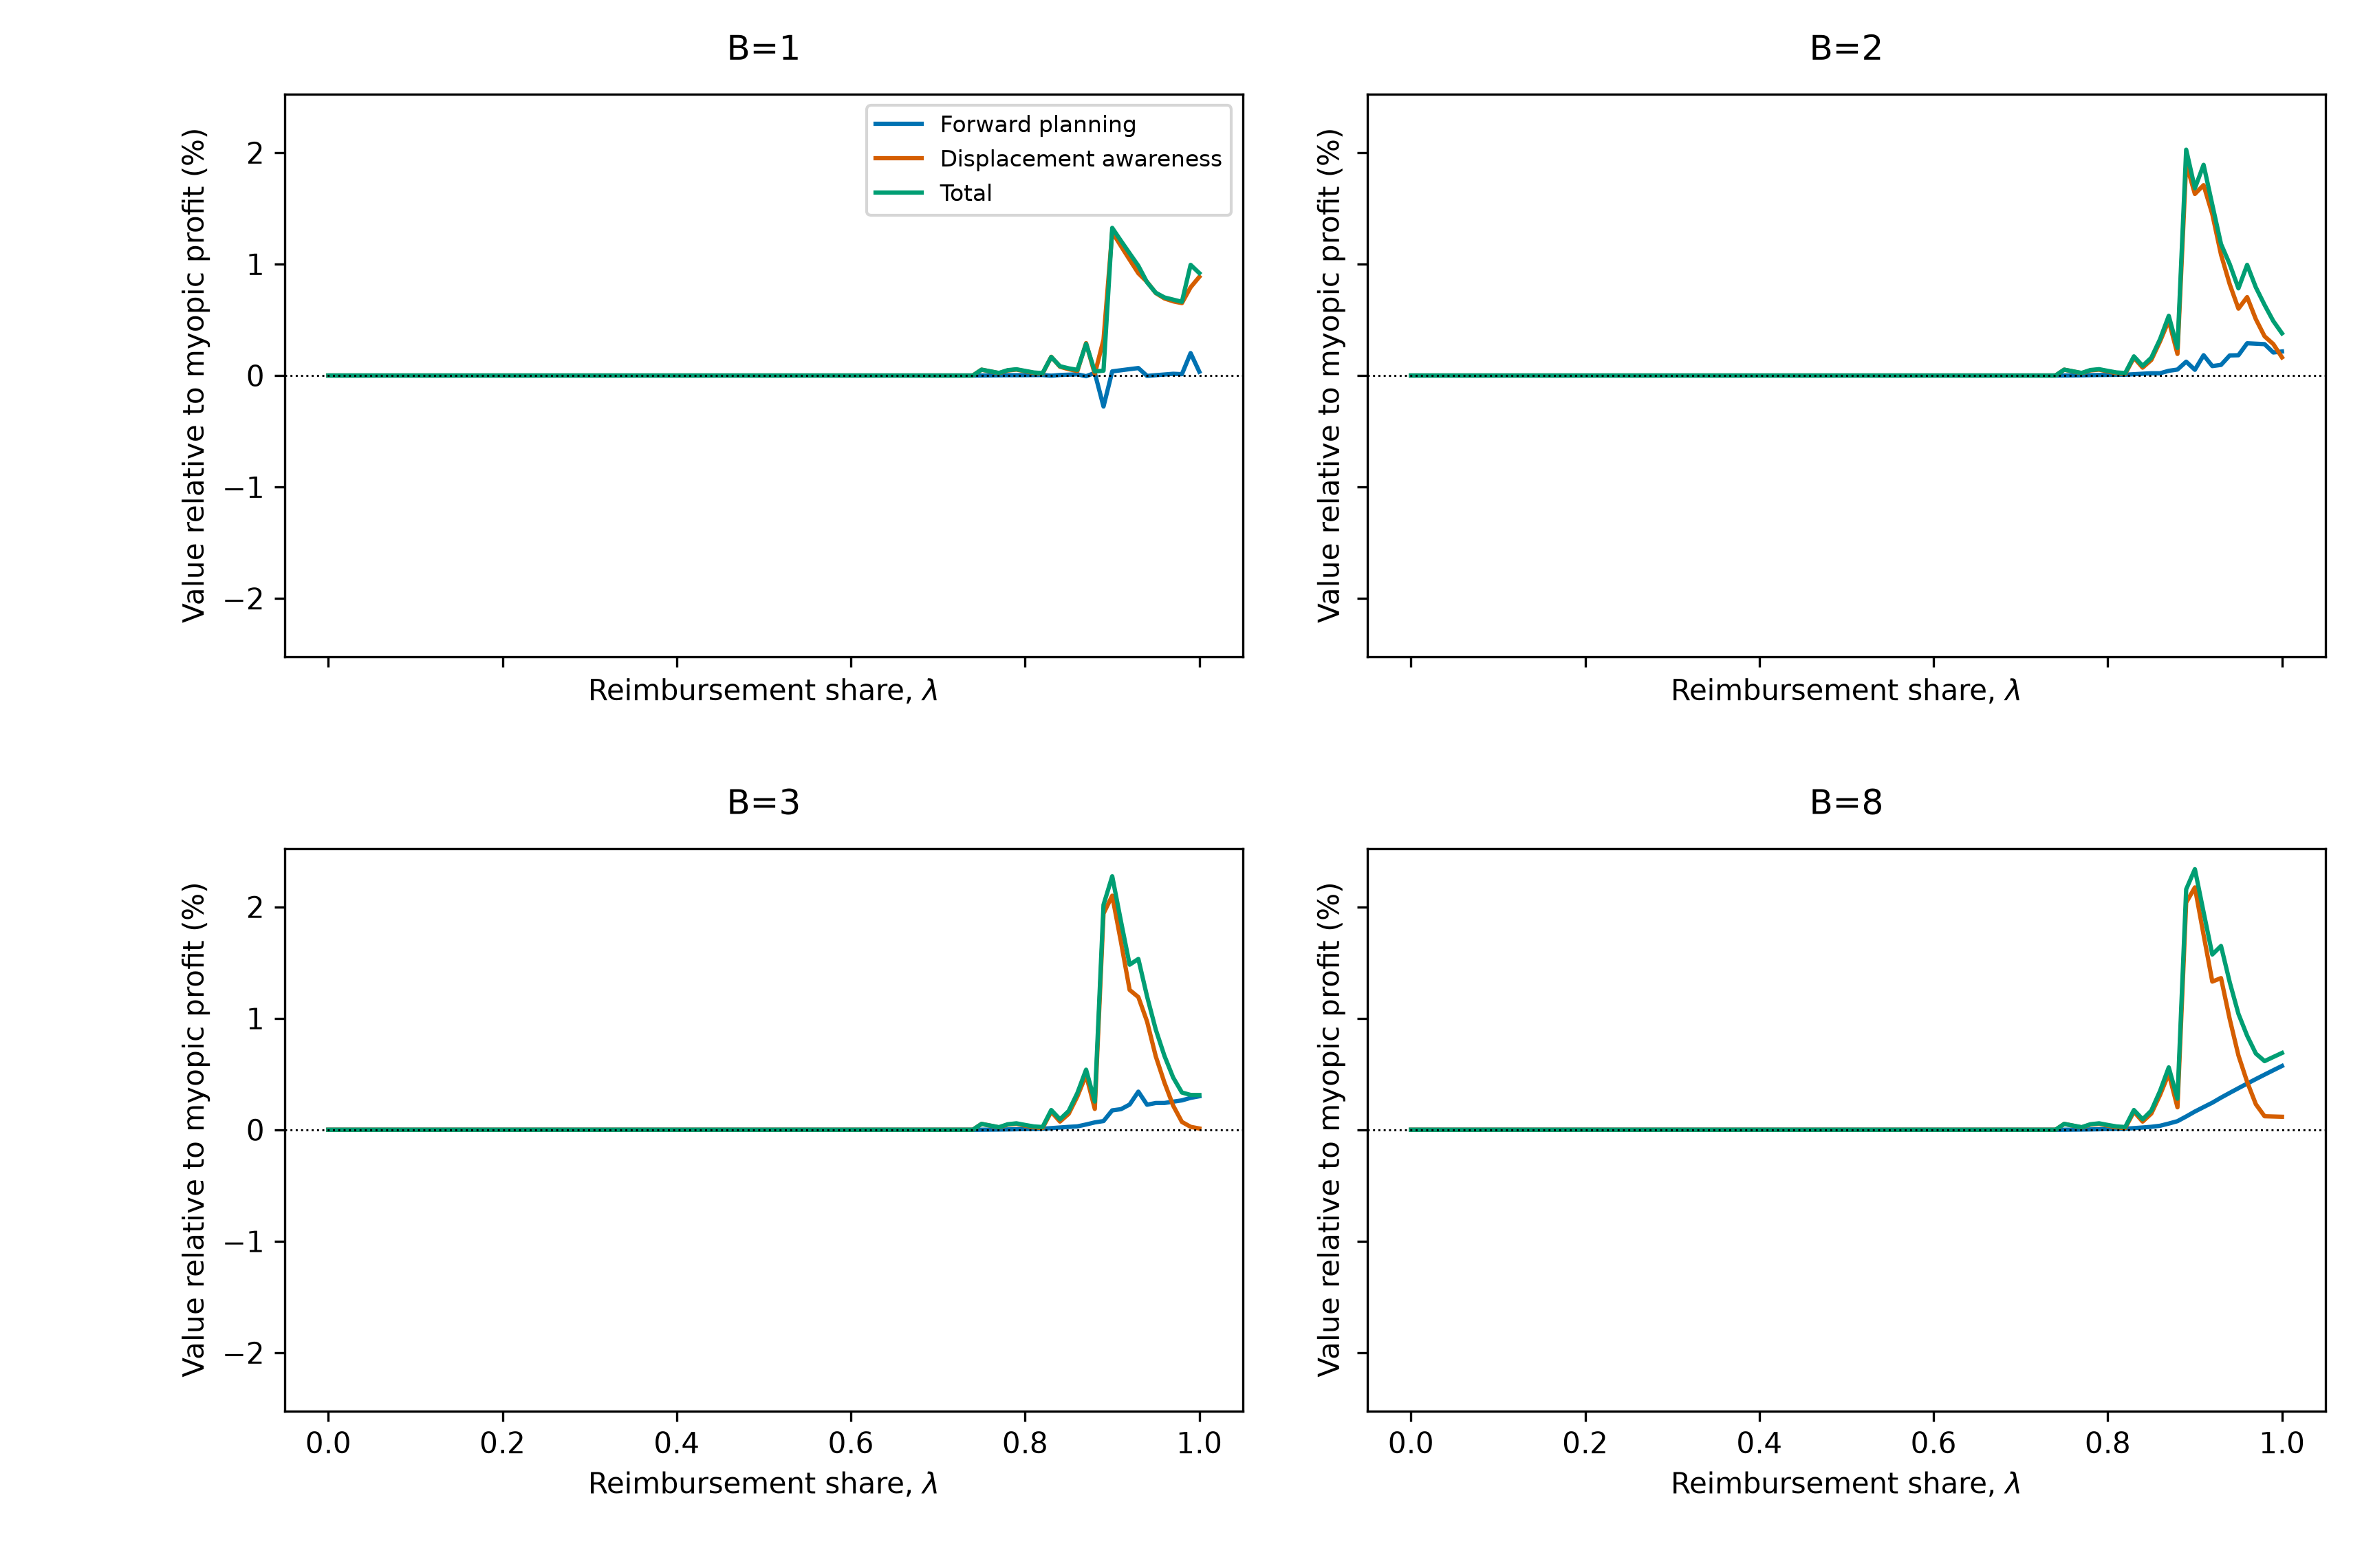

Detailed transition mechanism: B=1


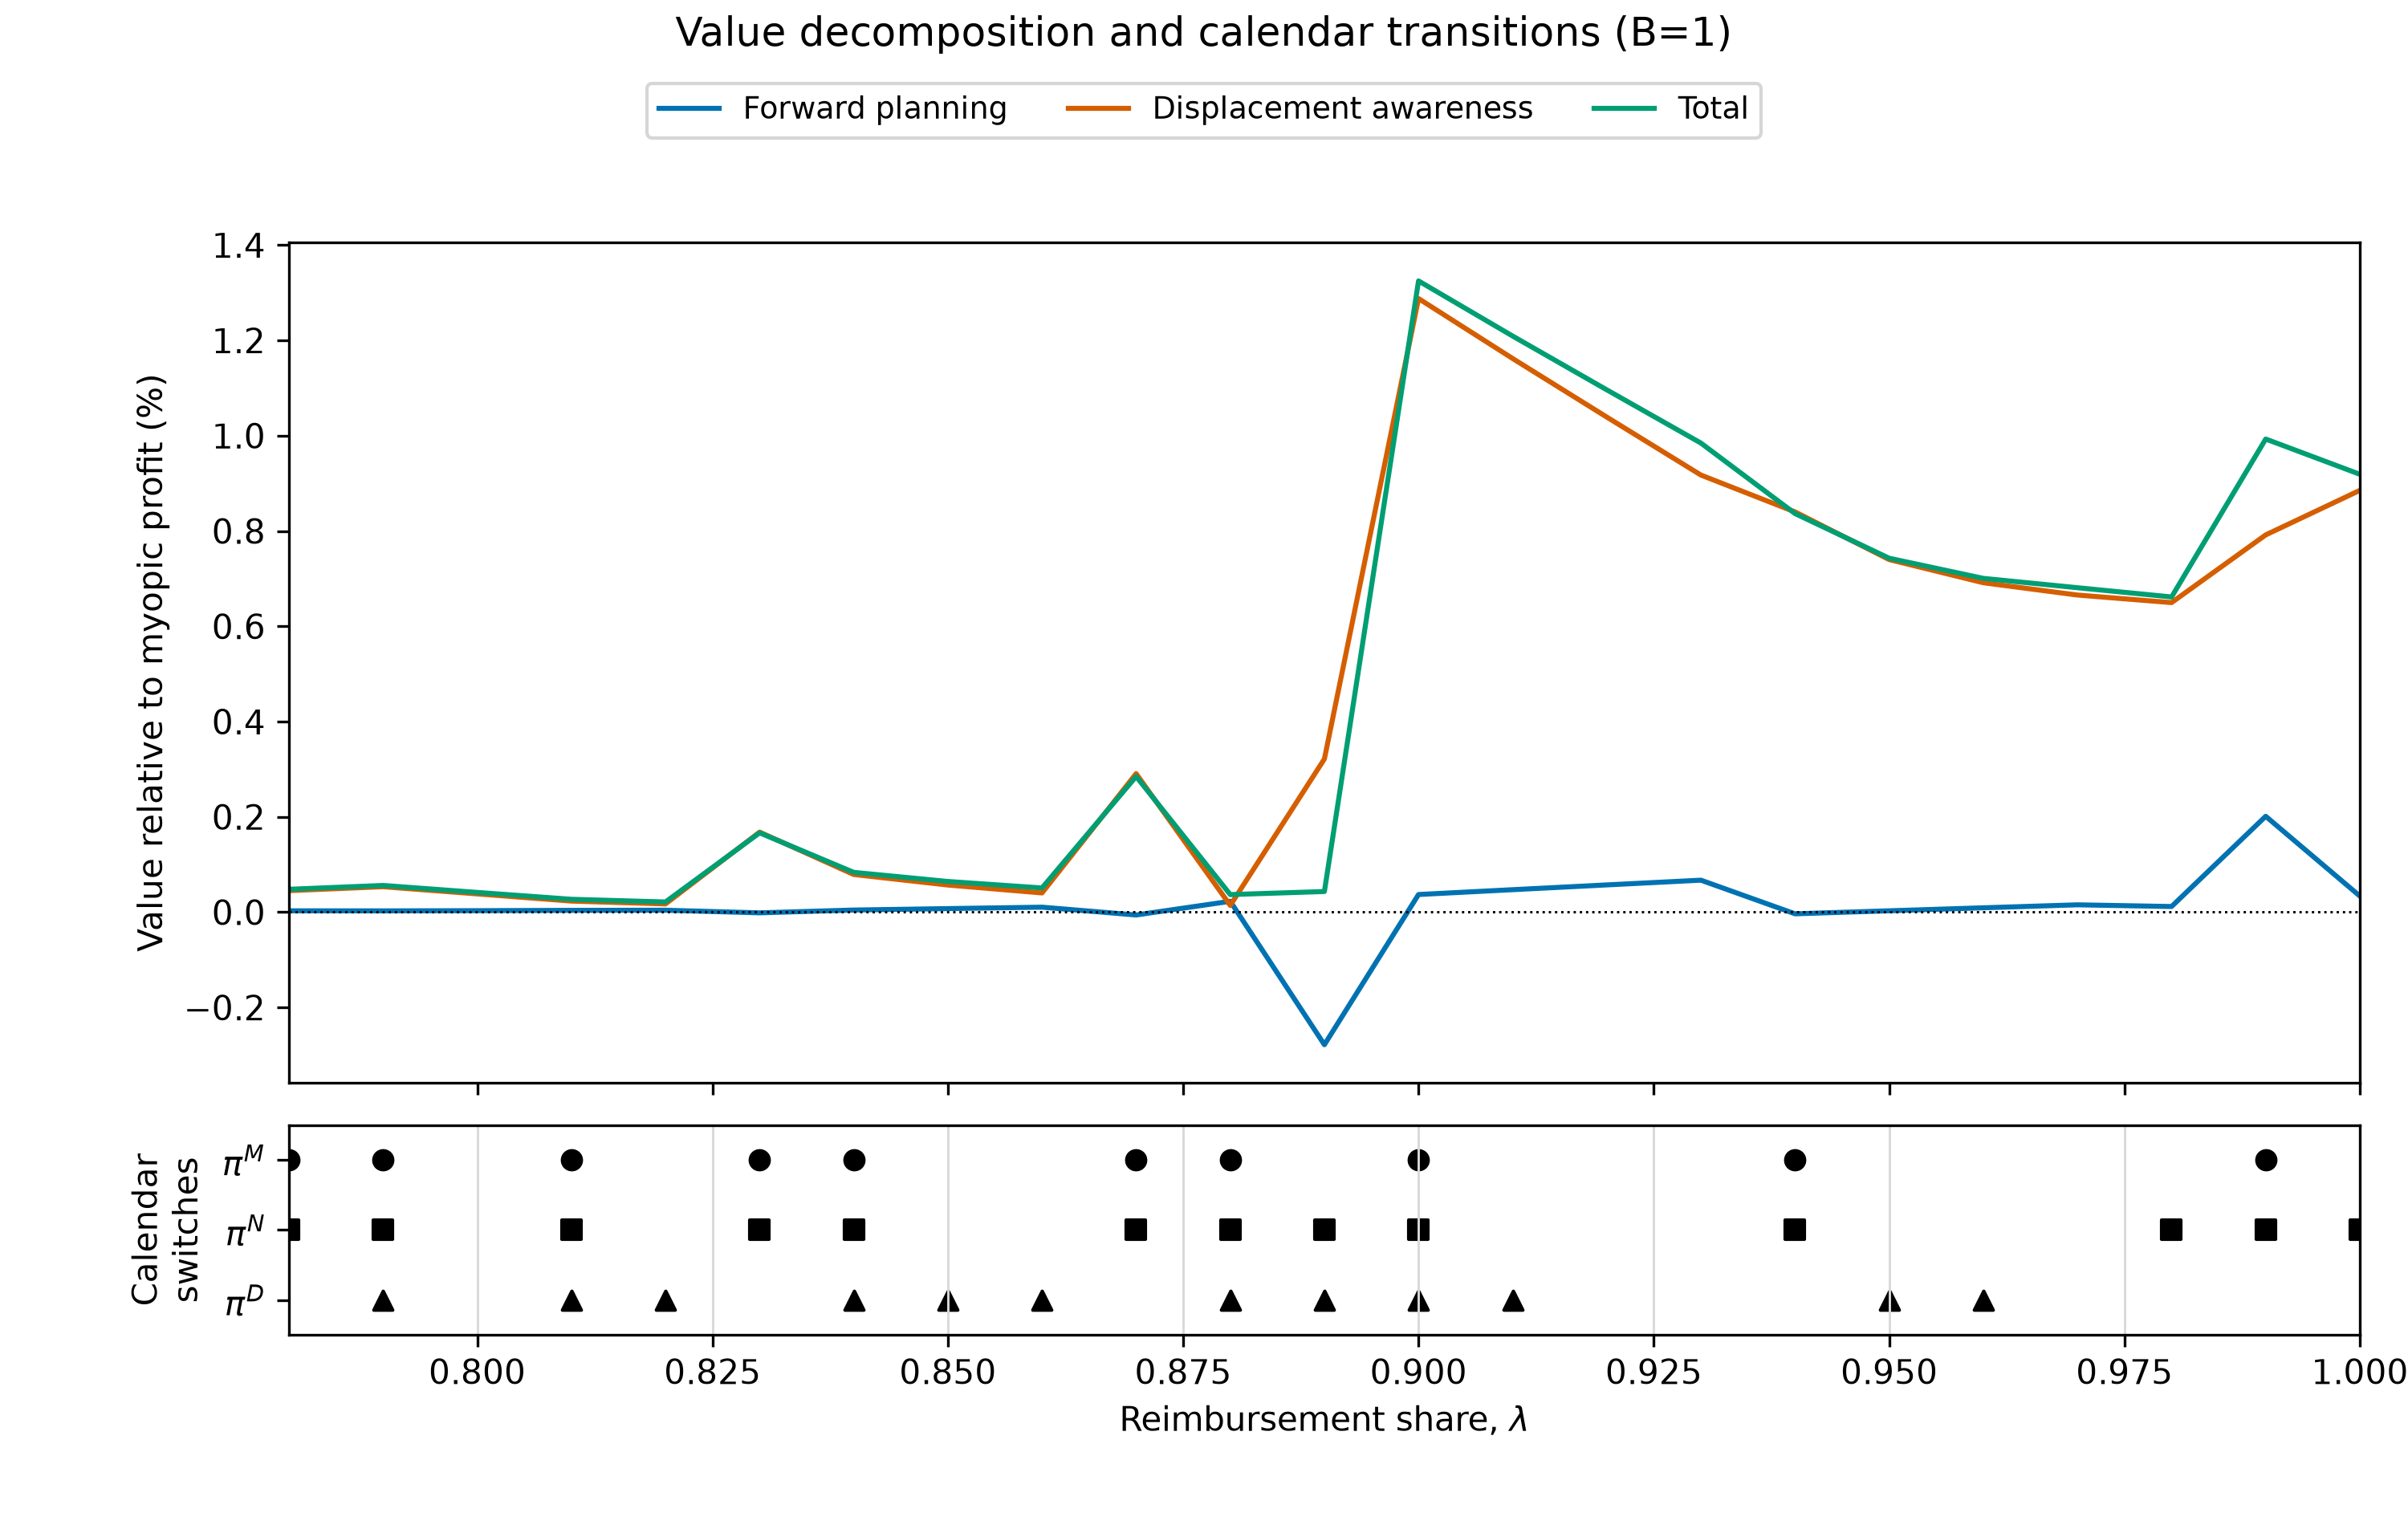

Detailed transition mechanism: B=2


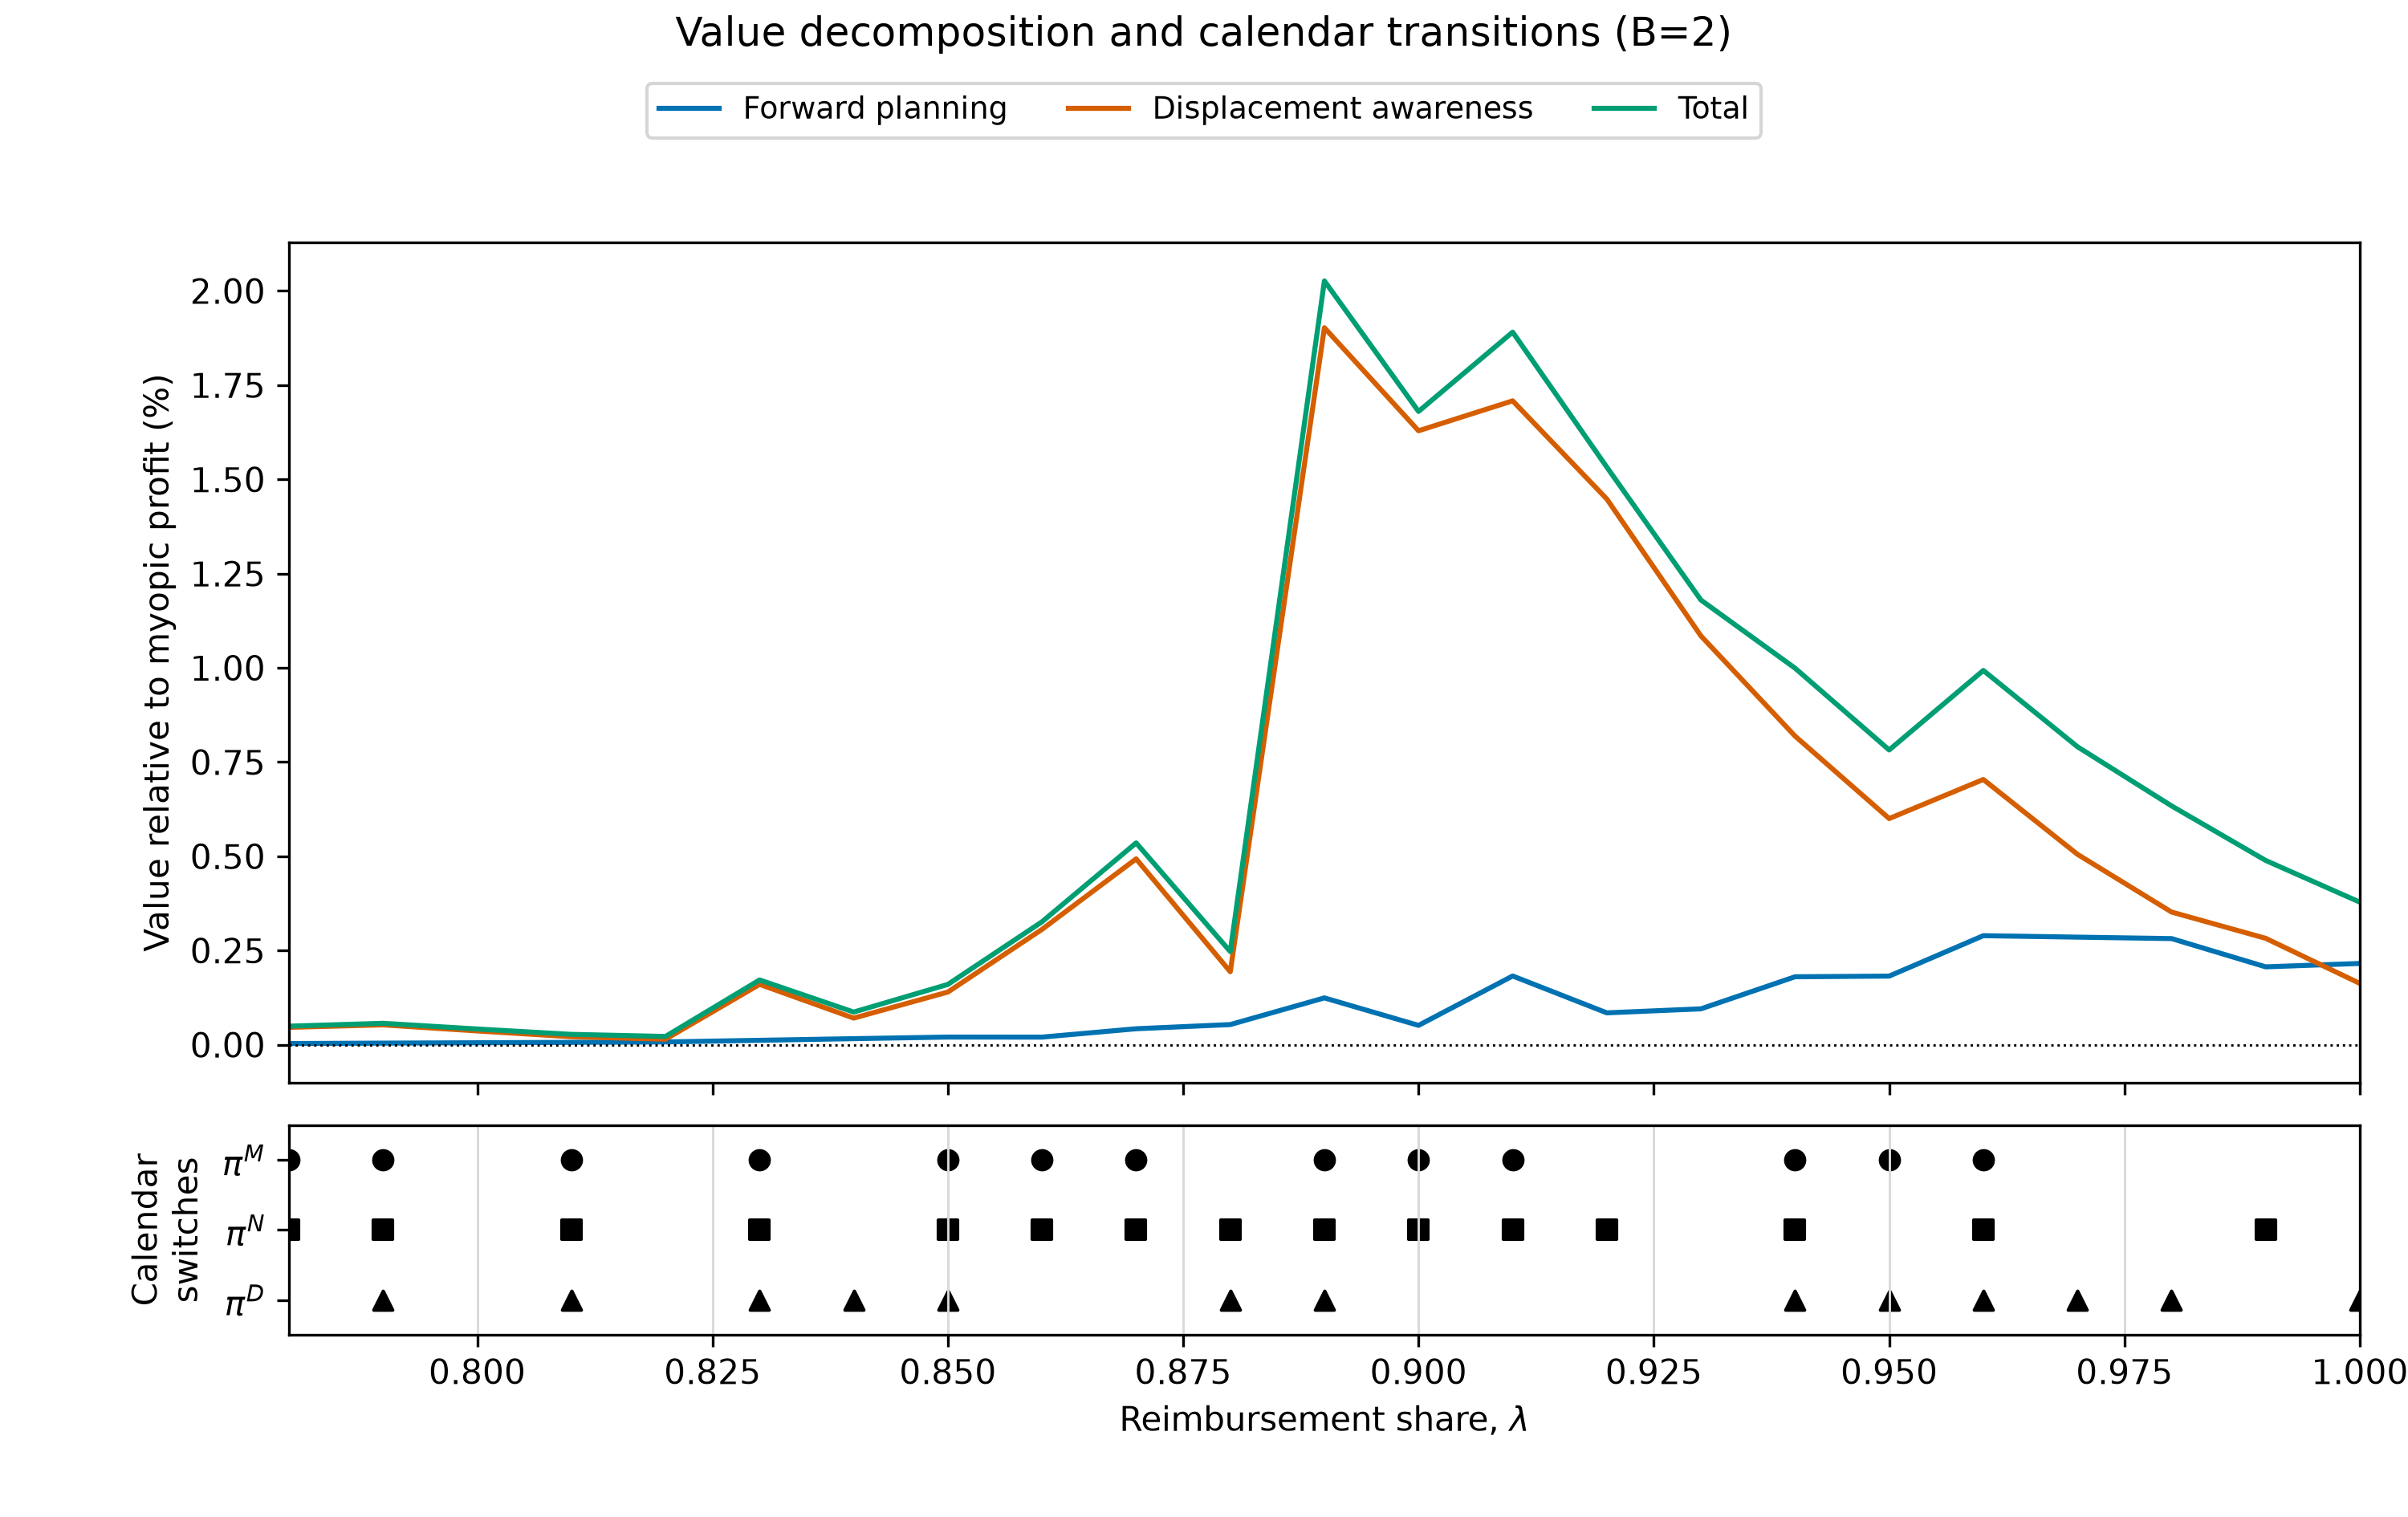

Detailed transition mechanism: B=3


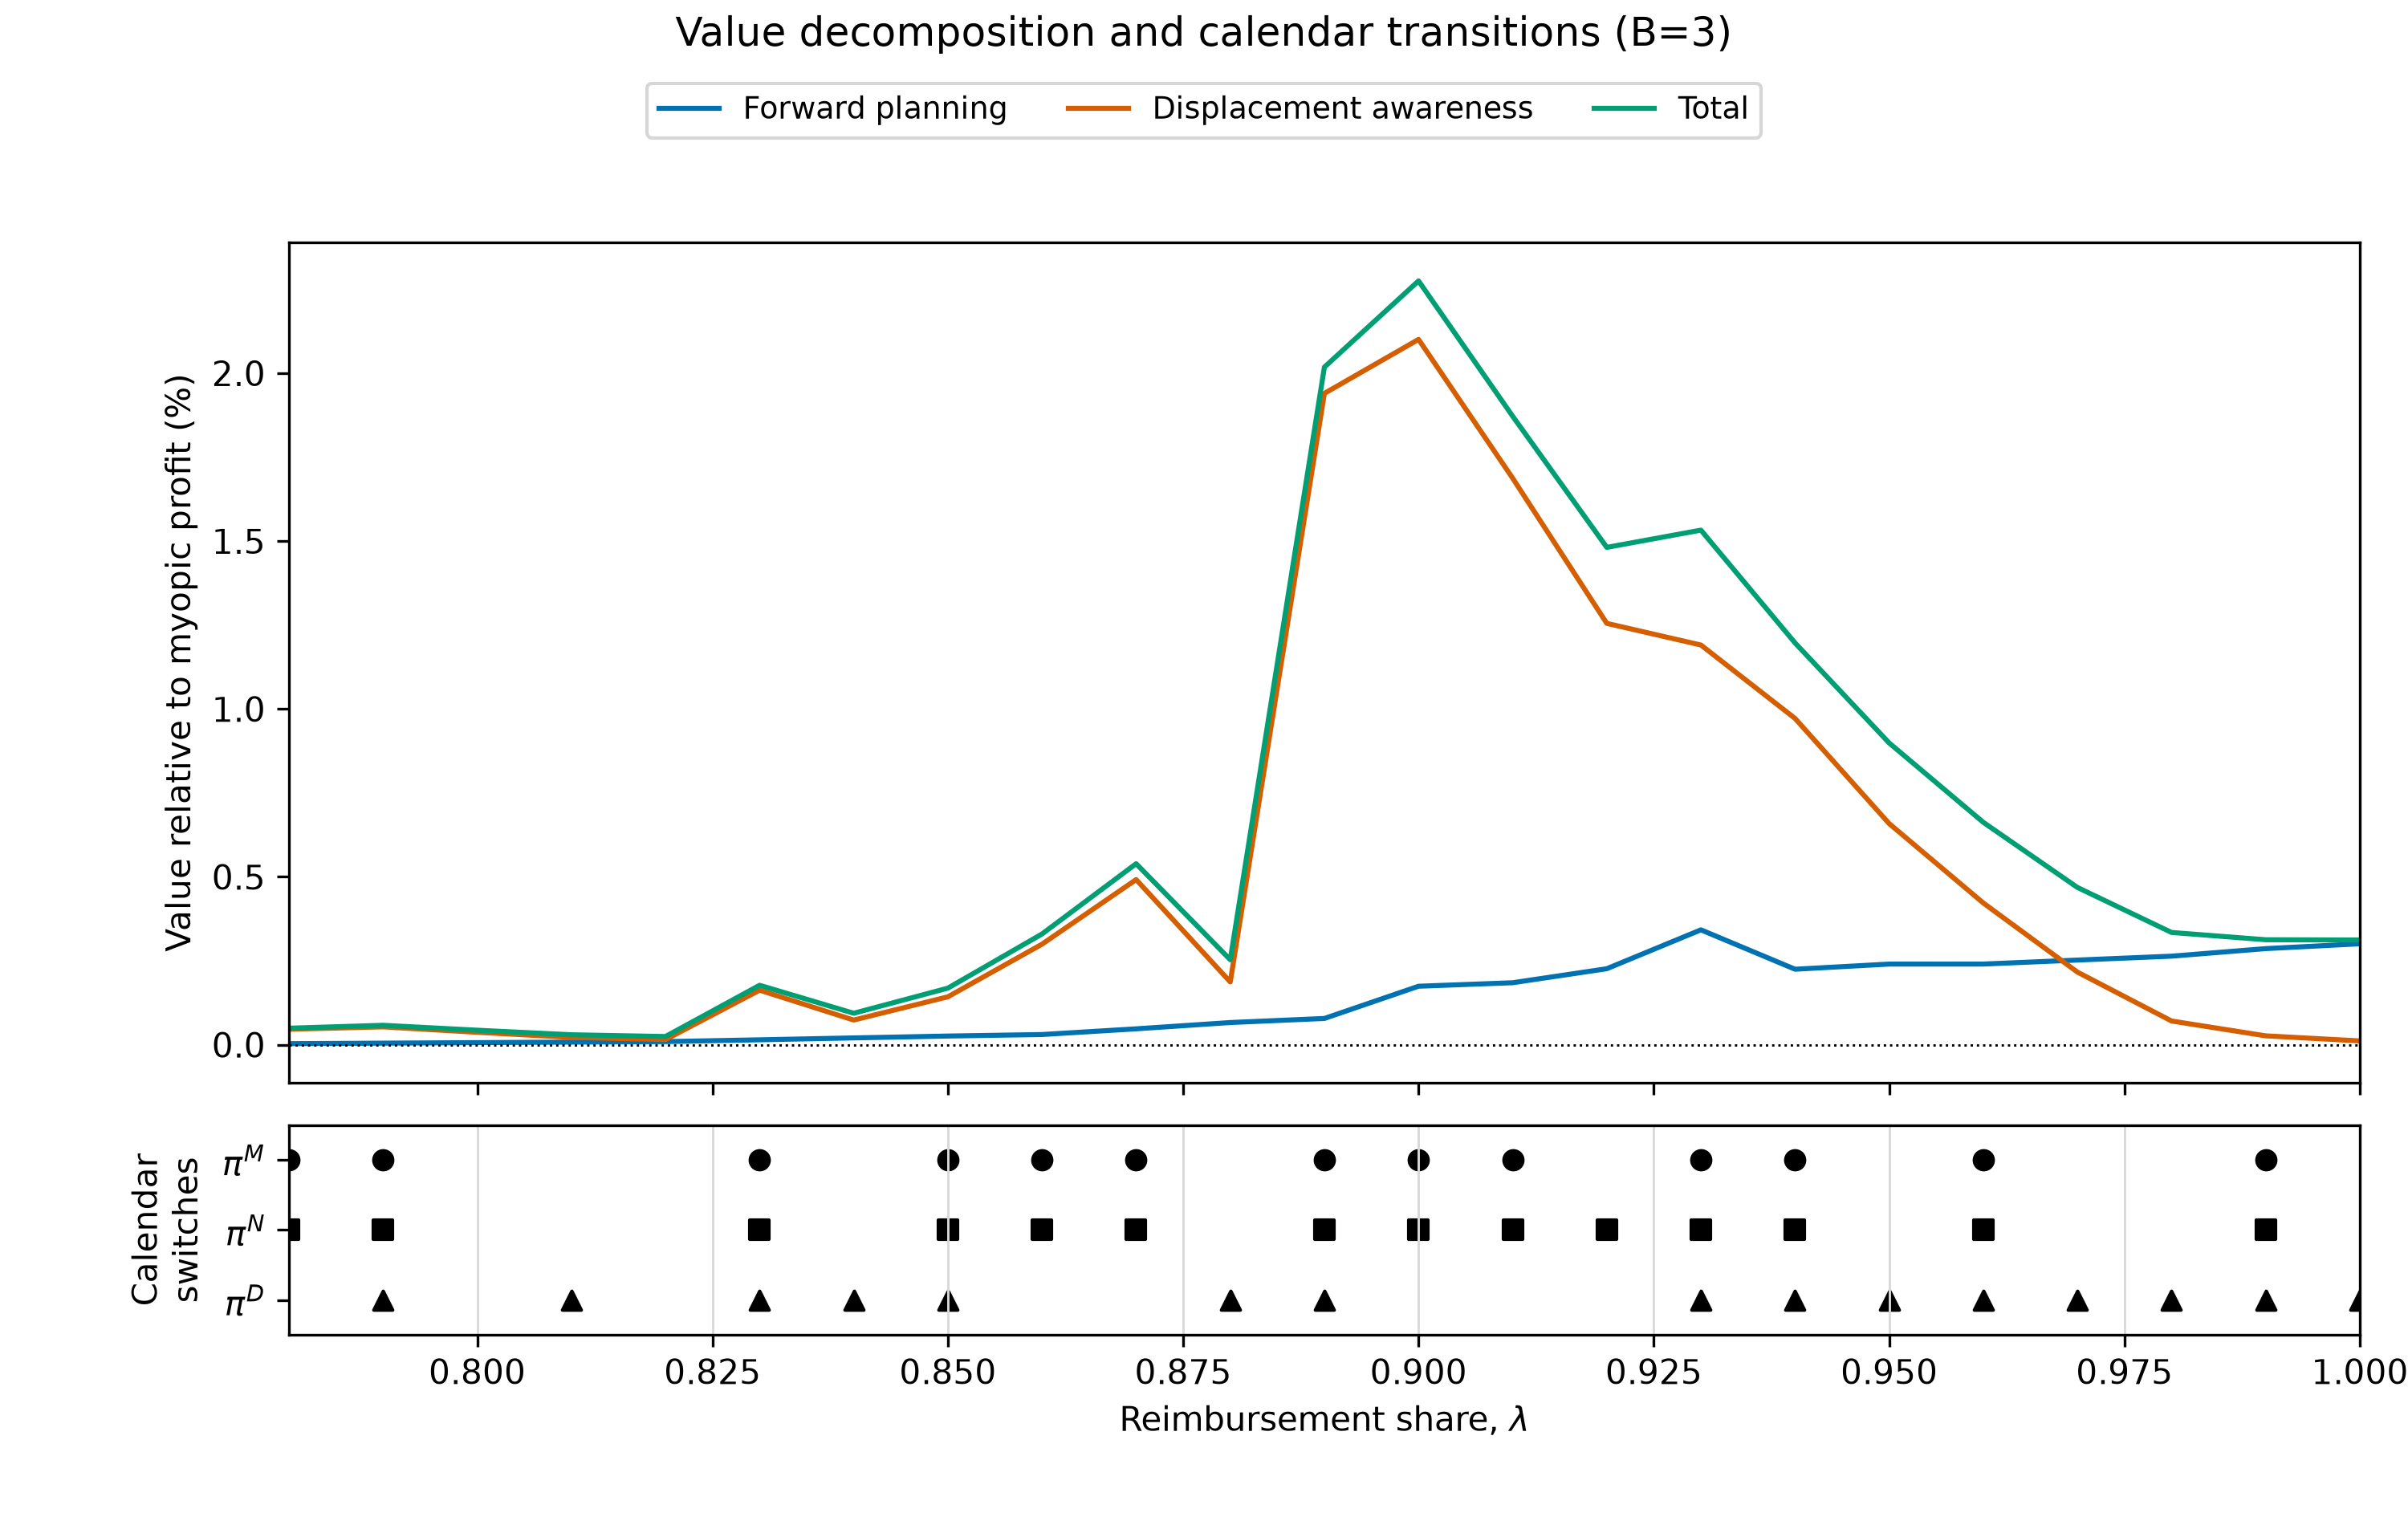

Detailed transition mechanism: B=8


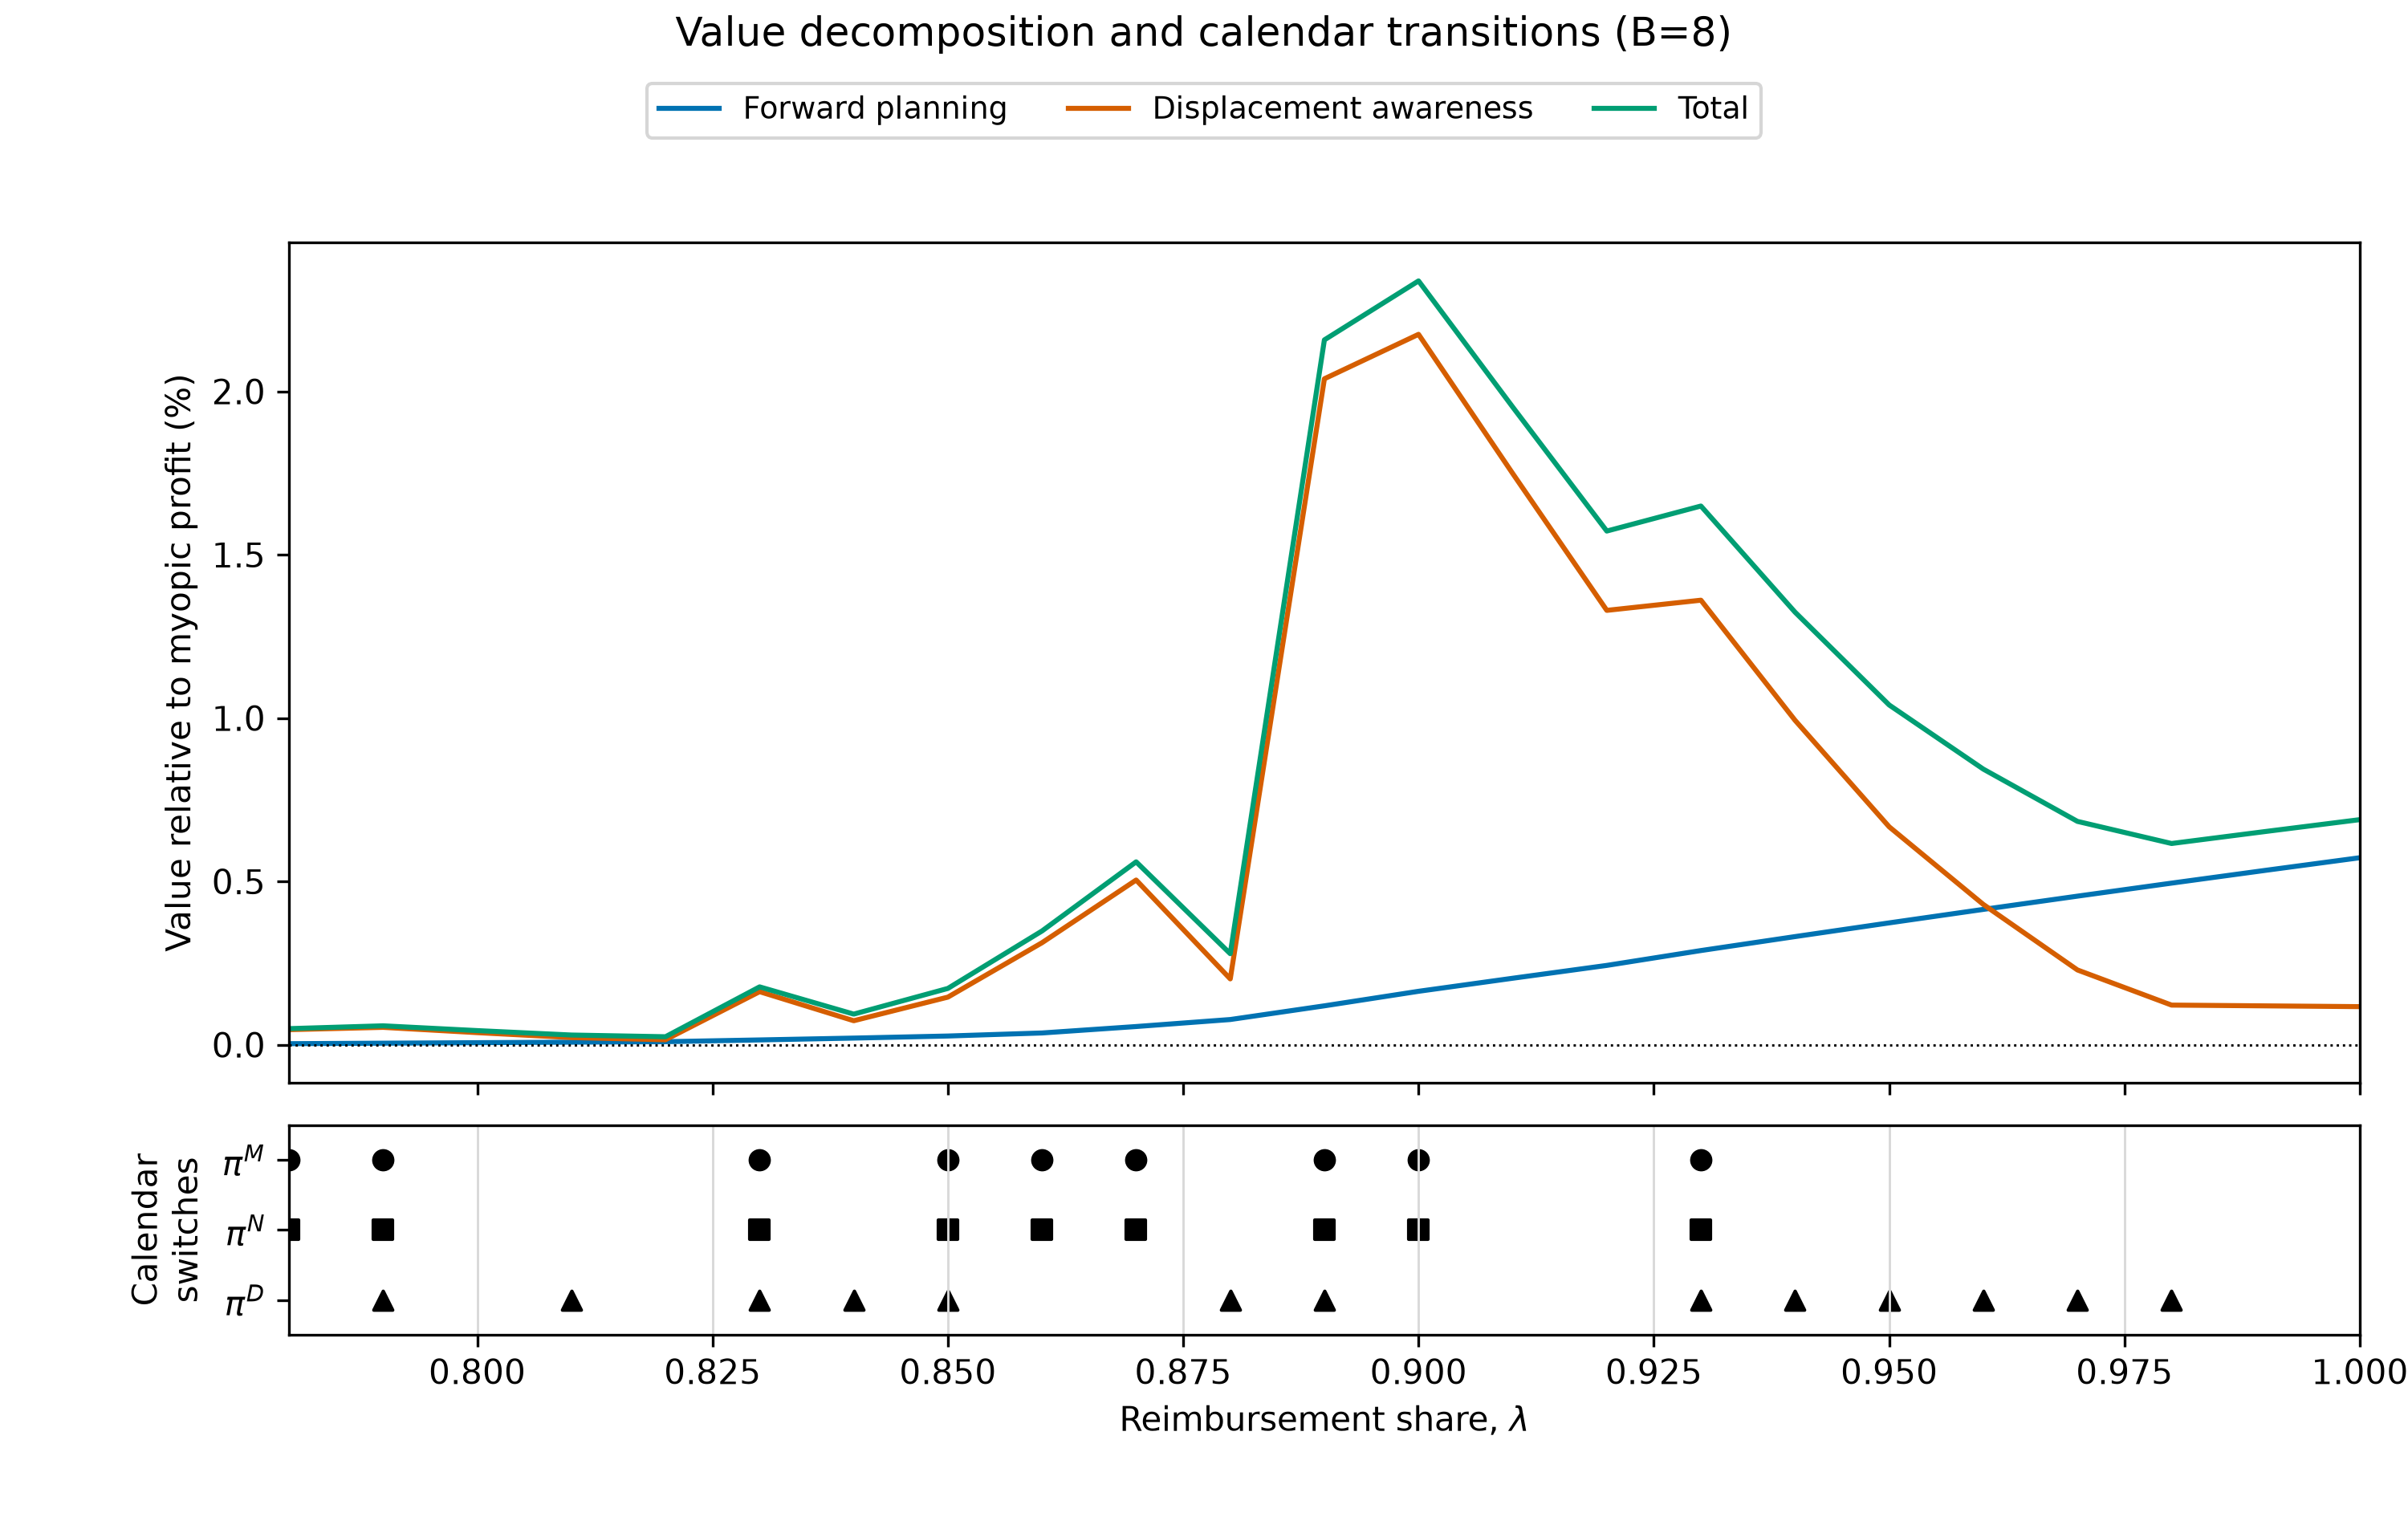

,reimbursement_share_previous,reimbursement_share,switching_policy,calendar_hash_before,calendar_hash_after,changed_product_week_decisions,changed_products,delta_plan_before,delta_disp_before,delta_total_before,delta_plan_after,delta_disp_after,delta_total_after
0,0.74,0.75,piM,dc6ed2ca1cb8699c,e971e1d2ee349b7f,4,3800001520,0.000000,0.000000,0.000000,0.335477,40.584949,40.920426
1,0.74,0.75,piN,dc6ed2ca1cb8699c,5f4a5629147b984d,4,3800001520,0.000000,0.000000,0.000000,0.335477,40.584949,40.920426
2,0.77,0.78,piM,e971e1d2ee349b7f,eb4a642fe5e2c04a,4,3800000127,1.501774,16.302544,17.804318,2.450779,35.792593,38.243372
3,0.77,0.78,piN,5f4a5629147b984d,1fcd96184dfb57d5,4,3800000127,1.501774,16.302544,17.804318,2.450779,35.792593,38.243372
4,0.78,0.79,piM,eb4a642fe5e2c04a,bdc4334bd9db644e,4,3800000120,2.450779,35.792593,38.243372,3.273395,40.859766,44.133162
5,0.78,0.79,piN,1fcd96184dfb57d5,433be05ea40d0e11,4,3800000120,2.450779,35.792593,38.243372,3.273395,40.859766,44.133162
6,0.78,0.79,piD,dc6ed2ca1cb8699c,88ea90319b36d0a9,4,3800001520,2.450779,35.792593,38.243372,3.273395,40.859766,44.133162
7,0.80,0.81,piM,bdc4334bd9db644e,56982aa0e8d08d51,16,3800000120|3800000127,4.029163,28.389290,32.418454,4.848185,16.505604,21.353790
8,0.80,0.81,piN,433be05ea40d0e11,f486e07c5ab01b8a,16,3800000120|3800000127,4.029163,28.389290,32.418454,4.848185,16.505604,21.353790
9,0.80,0.81,piD,88ea90319b36d0a9,7f3c241b8d89743f,4,3800000120,4.029163,28.389290,32.418454,4.848185,16.505604,21.353790


,capacity,piM_switches,piN_switches,piD_switches,max_total_gain_percent_myopic,reimbursement_share_at_max_total_gain,displacement_share_at_peak_percent,mean_dynamic_binding_weeks_lambda_ge_080
0,1,11,14,12,1.324761,0.90,97.204471,10.571429
1,2,14,16,13,2.026589,0.89,93.870617,6.952381
2,3,14,15,15,2.274818,0.90,92.342441,3.809524
3,8,10,10,13,2.338247,0.90,93.006253,0.476190


,policy_system,reimbursement_grid_points,products,occupancy_grid_checks,discarded_schedules,max_full_minus_retained_optimum_loss
0,piN,101,8,104232,23168,0.0
1,piD,101,8,104232,22984,0.0


,audit,capacity,reimbursement_share,finding,grid_points,calendar_identity_verified,zero_components_verified,value_piM,value_piN,value_piD,delta_plan,delta_disp,delta_total,piM_calendar_hash,piN_calendar_hash,changed_product_week_decisions,changed_products
0,low_reimbursement_identity,1,NaN,identical calendars and zero components below ...,80.0,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,low_reimbursement_identity,2,NaN,identical calendars and zero components below ...,80.0,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,low_reimbursement_identity,3,NaN,identical calendars and zero components below ...,80.0,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,low_reimbursement_identity,8,NaN,identical calendars and zero components below ...,80.0,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,negative_forward_planning_component,1,0.83,piN is evaluated below piM under common full-d...,NaN,False,False,291332.509087,291331.364047,291461.927604,-1.145040,130.563557,129.418518,1e1f65948c78e8a5,465e41811144762b,16.0,3800000120|3800001520
5,negative_forward_planning_component,1,0.87,piN is evaluated below piM under common full-d...,NaN,False,False,291485.548853,291480.911932,291707.716470,-4.636921,226.804538,222.167617,dc04bede44f47b8e,27a0725366675fc0,16.0,3800000120|3800001520
6,negative_forward_planning_component,1,0.89,piN is evaluated below piM under common full-d...,NaN,False,False,292077.157257,291858.499815,292111.193136,-218.657442,252.693321,34.035879,ffaa615ffad1f809,5f915c0869363050,20.0,3800000120|3800000127|3800001520|3800001611
7,negative_forward_planning_component,1,0.94,piN is evaluated below piM under common full-d...,NaN,False,False,293004.321563,293001.538388,293669.954169,-2.783175,668.415781,665.632606,65aa505a79a3ff46,3c55d7da2b803b82,16.0,3800001520|3800001611


In [20]:
from IPython.display import Image, display
import subprocess

report_script = PROJECT_ROOT / 'scripts' / 'build_three_policy_figures.py'
subprocess.run([sys.executable, str(report_script)], cwd=PROJECT_ROOT, check=True)

display(Image(filename=str(FIGURE_DIR / 'three_policy_components_by_capacity.png')))
for capacity in [1, 2, 3, 8]:
    print(f'Detailed transition mechanism: B={capacity}')
    display(Image(filename=str(FIGURE_DIR / f'three_policy_transitions_B{capacity}.png')))
display(pd.read_csv(TABLE_DIR / 'three_policy_transition_table_B2.csv').head(20))
display(pd.read_csv(TABLE_DIR / 'three_policy_transition_summary.csv'))
display(pd.read_csv(TABLE_DIR / 'candidate_pruning_exactness.csv'))
display(pd.read_csv(TABLE_DIR / 'three_policy_calendar_audit.csv'))